In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


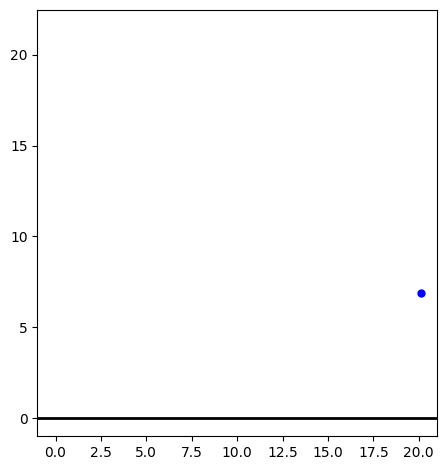

In [3]:
# ─── CONFIGURATION ────────────────────────────────────────────────────────────
x0 = 0   # initial x position
y0 = 10   # initial y position
vx0 = 1    # initial x velocity (m/s)
vy0 = 15    # initial y velocity (m/s)
Gravity = 9.81   # m/s²
RestitutionRate  = 0.99   # energy retained per bounce (0=no bounce, 1=perfect bounce)
Radius  = .1    # ball radius (m)
t_final = 20   # how many seconds to evaluate
t_step = 0.05   # time step (s)
# ─────────────────────────────────────────────────────────────────────────────

x, y = x0, y0  # Current x and y position of the ball
vx, vy = vx0, vy0  # Current x and y velocity of the ball

# Start plt.subplots without parameters. Hint: the subplot function returns a value for figure and second one for its axis
fig, ax = plt.subplots()

# X-limit determined by initial x, horizontal velocity, and total time
ax.set_xlim(-1, x0 + vx0 * t_final + 1)
# Y-limit determined by initial y, and the maximum height reached (Vy_0**2 / (2 * Gravity) is max height due to initial upward velocity)
ax.set_ylim(-1, max(y0, (vy0**2 / (2 * Gravity)) + y0) + 1)
# Lets plot a line to represent the floor
ax.axhline(0, color="black", linewidth=2)

ax.set_aspect("equal")

ball, = ax.plot(x, y, 'o', markersize=5, color="blue")

def update(frame):
    global x, y, vx, vy
    # Update vertical velocity based on gravity (kinematics equation: v = v0 + at)
    vy -= Gravity * t_step
    # Update horizontal position (kinematics equation: x = x0 + v0t)
    x  += vx * t_step
    # Update vertical position (kinematics equation: y = y0 + v0t)
    y  += vy * t_step
    # Check for collision with the ground (y <= Radius)
    if y <= Radius:
        y = Radius # Prevent ball from going below ground
        # Reverse vertical velocity and apply restitution (bounce) effect
        vy = -vy * RestitutionRate
    ball.set_data([x], [y])
    return (ball,)

anim = FuncAnimation(fig, update, frames=int(t_final / t_step), interval=t_step * 1000)
plt.tight_layout()
HTML(anim.to_jshtml())